# 1) k means clusterings

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [31]:
x,y_true = make_blobs(n_samples = 500,centers = 3, cluster_std = 0.60,random_state = 42)

In [32]:
df = pd.DataFrame(x, columns = ['Feature_1', 'Feature_2'])

In [33]:
df.head()

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [34]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [35]:
inertia = []
k_range = range(1,11)

In [36]:
for k in k_range:
    kmeans = KMeans(n_clusters = k , random_state = 42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [37]:
inertia

[1000.0,
 297.8954141051722,
 11.57548472310498,
 9.752067977356841,
 8.25717527244628,
 6.9175773204167985,
 6.334755391595287,
 5.70417717790143,
 5.060234133532076,
 4.762361898130397]

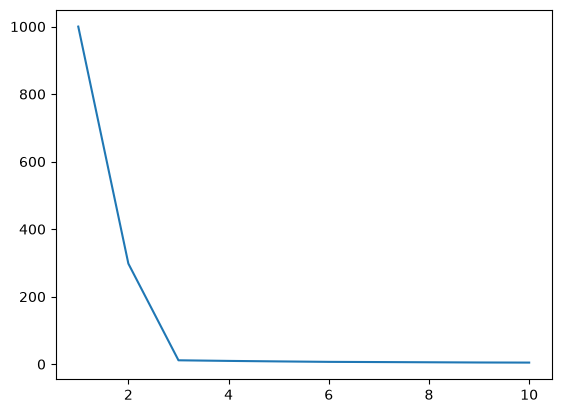

In [38]:
plt.plot(k_range,inertia)

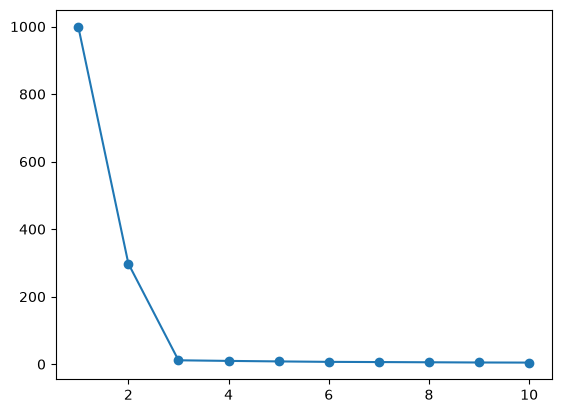

In [39]:
plt.plot(k_range,inertia , marker = 'o')

In [40]:
kmeans_final = KMeans(n_clusters = 3, random_state = 42)



In [41]:
cluster_labels = kmeans_final.fit_predict(x_scaled)

In [42]:
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [43]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

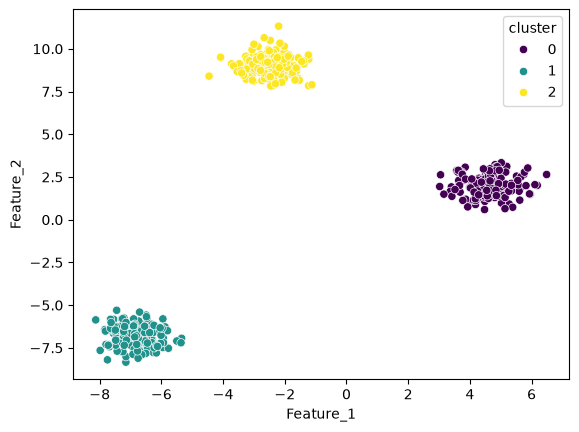

In [44]:
sns.scatterplot(
    x = df['Feature_1'],
    y = df['Feature_2'],
    hue = df['cluster'] ,
    palette = 'viridis'
)

# 2) DBScan

In [45]:
from sklearn.datasets import make_moons

In [46]:
x,y_true = make_moons(n_samples = 500 ,noise = 0.05 , random_state = 42)

In [47]:
from sklearn.cluster import DBSCAN


In [48]:
df_2 = pd.DataFrame(x,columns = ['Feature_1' , 'Feature_2'])

In [49]:
scaler = StandardScaler()
x_scaled_2 = scaler.fit_transform(df_2)

# first trying using kmeans 

In [50]:
kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans_labels = kmeans.fit_predict(x_scaled_2)


In [52]:
df_2['kmeans_clusters'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

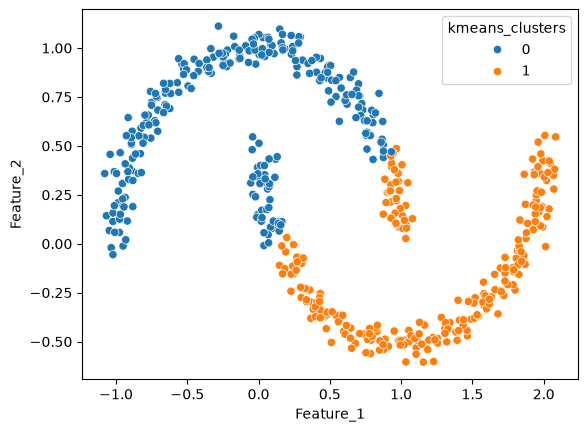

In [60]:
sns.scatterplot(
    x = df_2['Feature_1'],
    y = df_2['Feature_2'],
    hue = df_2['kmeans_clusters'] ,
    palette = 'tab10'
)

# now using DBScan

In [66]:
dbscan = DBSCAN(eps = 0.3,min_samples = 5)
dbscan_labels = dbscan.fit_predict(x_scaled_2)

In [67]:
df_2 ['dbscan_clusters'] =  dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

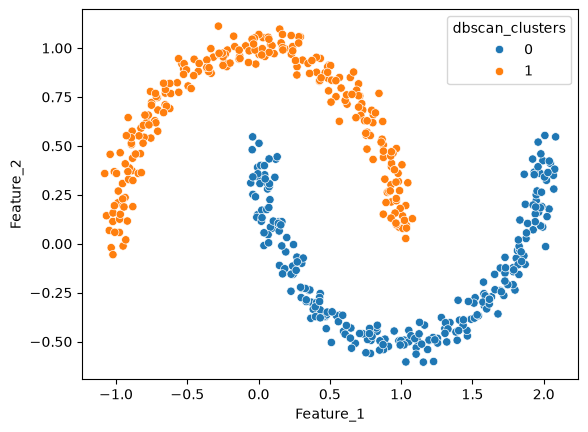

In [68]:
sns.scatterplot(
    x = df_2['Feature_1'],
    y = df_2['Feature_2'],
    hue = df_2['dbscan_clusters'] ,
    palette = 'tab10'
)

# 3) PCA

In [69]:
from sklearn.decomposition import PCA


In [70]:
x,y = make_blobs(n_samples = 500,n_features = 5 ,centers = 3, cluster_std = 0.60,random_state = 42)

In [71]:
x

array([[-9.6958364 ,  9.44770466,  6.55203419, -6.17896116, -6.96231856],
       [-8.97185719,  8.99996482,  6.55309608, -5.18623479, -6.49925718],
       [-3.00028215,  8.11262712,  4.48343774,  1.29791828, -6.96904919],
       ...,
       [-6.45928575, -8.21969001,  7.38864852,  2.29987604,  5.43216513],
       [-2.50011166,  9.27953054,  5.26869068,  1.59602784, -7.14632644],
       [-7.58367155, -9.57840862,  7.74052166,  3.19022594,  4.00515242]],
      shape=(500, 5))

In [72]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [75]:
pca= PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)

In [76]:
df_pca = pd.DataFrame(x_pca , columns = ['PC1','PC2'])
df_pca['label'] = y

In [77]:
df_pca

,PC1,PC2,label
0,-0.715957,-2.061223,2
1,-0.647788,-1.708740,2
2,-1.628715,1.226316,0
3,2.003938,0.576239,1
4,-0.445342,-1.997863,2
...,...,...,...
495,-1.647480,1.669963,0
496,-1.322440,1.287616,0
497,2.318513,0.719911,1
498,-1.455987,1.148050,0


<Axes: xlabel='PC1', ylabel='PC2'>

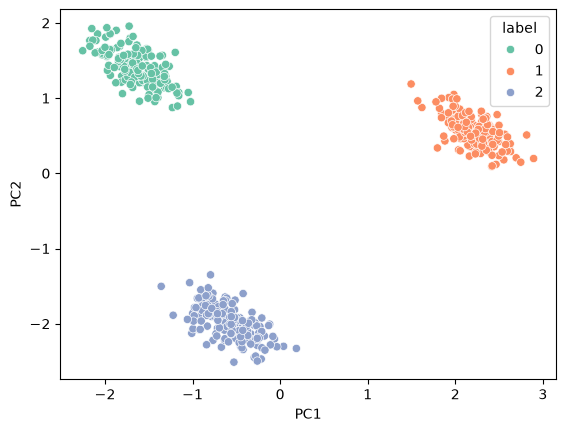

In [78]:
sns.scatterplot(
    data=df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = 'label' ,
    palette = 'Set2'
)